# Cleaning raw data2

In [1]:
import pandas as pd
import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import re
import os
import ipywidgets as widgets
from IPython.display import display, clear_output

In [2]:
xlsx_path = "input_folder/dataset_2020-2023_RanaK_20250430.xlsx"

In [3]:
age_groups = {
    'Neonate': (0, 1),
    'Infant': (1, 2),
    'Toddler': (2, 5),
    'Child': (5, 12),
    'Adolescent': (12, 18),
    'Young Adult': (18, 30),
    'Adult': (30, 45),
    'Middle-aged Adult': (45, 60),
    'Older Adult': (60, 75),
    'Elderly': (75, 85),
    'Very Elderly': (85, float('inf')),
}

amr_custom_color_map = {
    'ESBL-EC': '#0B5394',
    'ESBL-KP': '#3D85C6',
    'CRE': '#9FC5E8',
    'CR-AB': '#3360BC',
    'MRSA': '#674EA7',
    'VRE': '#7030A0',
    'CR-PA': '#7030A0',
    'AMP-RHI': '#00B0F0',
    'MAC-RSP': '#00B0F0',
    'MAC-RSPN': '#00B0F0',
    # 'PEN-R': '#66c2a5',
}


amr_custom_color_map2 = {
    'ESBL-EC': '#0B5394',
    'ESBL-KP': '#0B5394',
    'CRE': '#0B5394',
    'CR-AB': '#0B5394',
    'MRSA': '#6A329F',
    'VRE': '#6A329F',
    'CR-PA': '#6A329F',
    'AMP-RHI': '#9FC5E8',
    'MAC-RSP': '#9FC5E8',
    'MAC-RSPN': '#9FC5E8',
    # 'PEN-R': '#66c2a5',
}

def categorize_age(age):
    for group, (min_age, max_age) in age_groups.items():
        if min_age <= age < max_age:
            return group
    return 'Unknown'

In [4]:
yrs_int = [2020, 2021, 2022, 2023]
yrs = [str(y) for y in yrs_int]
dfs = []

def read_raw_data(yr):
    df = pd.read_excel(xlsx_path, sheet_name=yr)
    df.set_index("Patient ID", drop=False, inplace=True)

    # clean string columns
    for c in ["Gender", "Ward", 'Type of Sample']:
        df[c] = df[c].str.strip().str.title()

    typeOfSample_replace = {
        "Stool Cluture": "Stool Culture",
        "Peritonial Fluid": "Peritoneal Fluid",
        "Axillary Aspiration": "Axillary Swab",
        "Fluid": "Bronchoalveolar Lavage"}
    df["Type of Sample"] = df["Type of Sample"].replace(typeOfSample_replace)
    
    organism_replace = {
        'Acinetobacter baumanii': 'Acinetobacter baumannii',
        'Aeromonas hydrophilia': 'Aeromonas hydrophila',
        'Bacteroides species': 'Bacteroides spp',
        'Enterobacteriacae': 'Enterobacteriaceae',
        'Flaviobacterium spp': 'Flavobacterium spp',
        'Klebsiella spp.': 'Klebsiella spp',
        'Micrococcus species': 'Micrococcus spp',
        'Providencia  stuartii': 'Providencia stuartii',
        'Streptococcus group c': 'Streptococcus Group C'
    }
    df["Organism"] = df["Organism"].str.strip().str.capitalize()
    df["Organism"] = df["Organism"].replace(organism_replace)

    typeOfAMR_replace = {"": np.nan, "-": np.nan, "CRE CP Producer": "CRE", "MRSE": np.nan}
    
    df["Type of AMR"] = df["Type of AMR"].str.strip()
    df["Type of AMR"] = df["Type of AMR"].replace(typeOfAMR_replace)
    
    df["Year"] = int(yr)
    # df["Year"] = pd.to_datetime(yr, format="%Y")
    
    # df['Date of Birth'] = pd.to_datetime(df['Date of Birth'], format='%d/%m/%Y')
    df['Date of Birth'] = pd.to_datetime(df['Date of Birth'])
    reference_date = pd.Timestamp(f'{yr}-12-31')
    df['Age'] = (reference_date - df['Date of Birth']).dt.days // 365
    df['Age2'] = (reference_date - df['Date of Birth']).dt.days / 365
    df['Age Group'] = df['Age2'].apply(categorize_age)

    df['Date of Request'] = pd.to_datetime(df['Date of Request'], format='%d/%m/%Y')

    return df

    
for yr in yrs:
    # print(yr)
    sdf = read_raw_data(yr)
    dfs.append(sdf)

df = pd.concat(dfs)
df.sort_values("Year", inplace=True)


/tmp/ipykernel_136829/3358623705.py:43: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date of Birth'] = pd.to_datetime(df['Date of Birth'])


Columns: 

In [5]:
df.columns.tolist()

['Sample ID',
 'Patient ID',
 'Gender',
 'Date of Birth',
 'Age',
 'Ward',
 'Type of Sample',
 'Date of Request',
 'Organism',
 'Type of AMR',
 'Year',
 'Age2',
 'Age Group']

Cleaning data, problems from raw data:

- Gender: `['Male', 'Female', 'Male ', 'male ']`
- Date of Birth
- Age

Dates, I'm assuming it follows the format `%d/%m/%Y`, and I recalculate age too.

## How many entries per year?

In [6]:
def count_entries(col, nonorm=False):
    counts = []
    
    df2 = df.copy().drop_duplicates("Patient ID")
    if nonorm:
        df2 = df.copy()
    
    cc = df2[col].unique()
    for c in cc:
        count = df2.loc[df2[col] == c, :].index.shape[0]
        counts.append(count)
        # print(c, z1)
    
    d = pd.DataFrame([cc, counts, cc]).T
    d.columns = [col, "Count", "Color"]
    d["Color"] = d["Color"].astype(str)

    d.sort_values("Count", inplace=True)
    return d

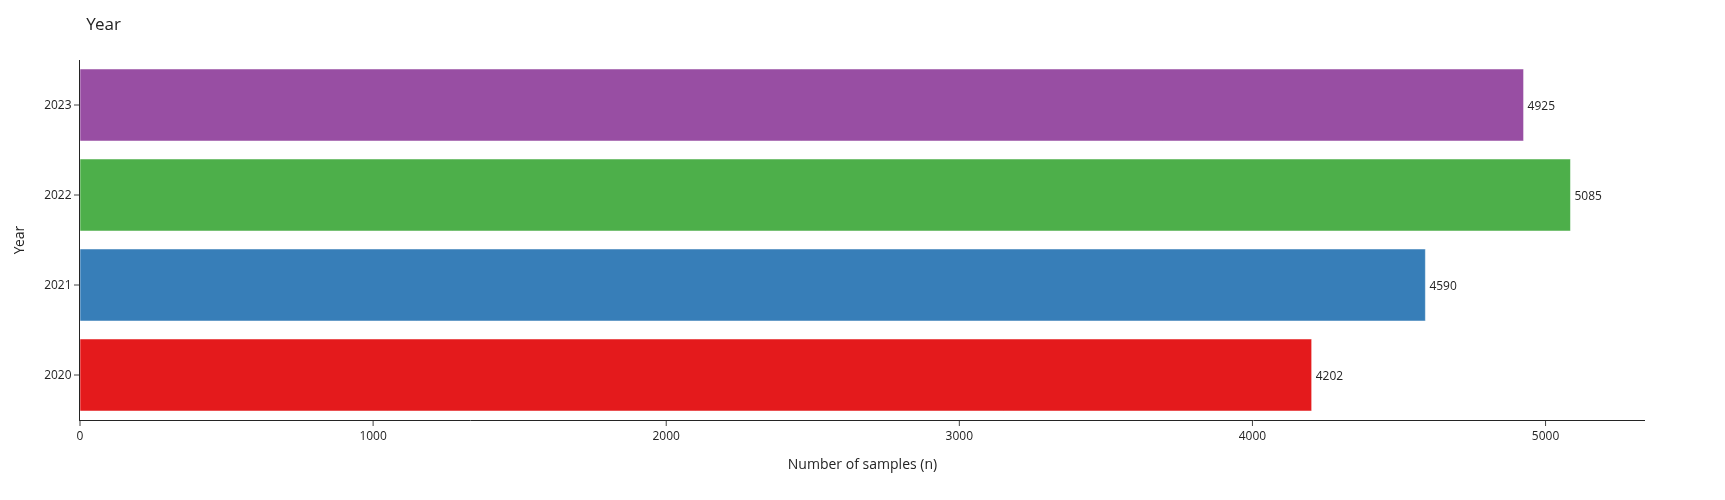

In [7]:
year_df = count_entries("Year", nonorm=True)

color_discrete_map = {'2020': px.colors.qualitative.Set1[0], '2021': px.colors.qualitative.Set1[1],
'2022': px.colors.qualitative.Set1[2], '2023': px.colors.qualitative.Set1[3],
}

fig = px.bar(
    year_df,
    x='Count',
    y='Year',
    orientation='h',
    text='Count',
    color='Color',  # use the custom color mapping
    color_discrete_map=color_discrete_map,
    category_orders = {"Year": yrs},
)

fig.update_layout(
    title='Year', template="simple_white",
    xaxis=dict(
        title="Number of samples (n)",
        range=[0, year_df['Count'].max() * 1.05]
    ),
    width=800, height=500,
    showlegend=False,  # now this actually works
    yaxis=dict(
        tickmode='array',
        tickvals=yrs,
        ticktext=yrs  # Set tick text to be the same as tick values
    )
)

fig.update_traces(textposition='outside')
fig.show()

## Gender

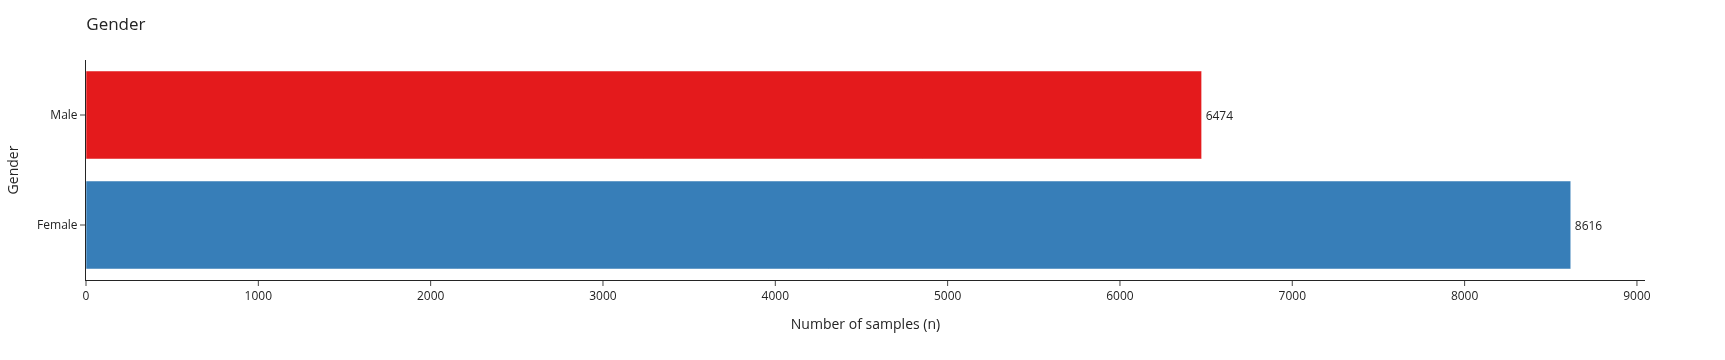

In [8]:
plot_df = count_entries("Gender")

fig = px.bar(
    plot_df, x='Count', y='Gender', orientation='h', text='Count', color='Gender',
    color_discrete_sequence=px.colors.qualitative.Set1
)

# Tweak layout and labels
fig.update_layout(
    title='Gender', template="simple_white",
    xaxis=dict(
        title="Number of samples (n)",
        range=[0, plot_df['Count'].max() * 1.05]
    ),
    showlegend=False,
    width=800
)

fig.update_traces(textposition='outside')
fig.show()

## Date of Birth

In [9]:
eldest = df["Date of Birth"].min()
youngest = df["Date of Birth"].max()

print(f"""Eldest: {eldest},
Youngest: {youngest}""")

Eldest: 1914-01-01 17:18:35,
Youngest: 2023-12-24 10:15:28


## Age

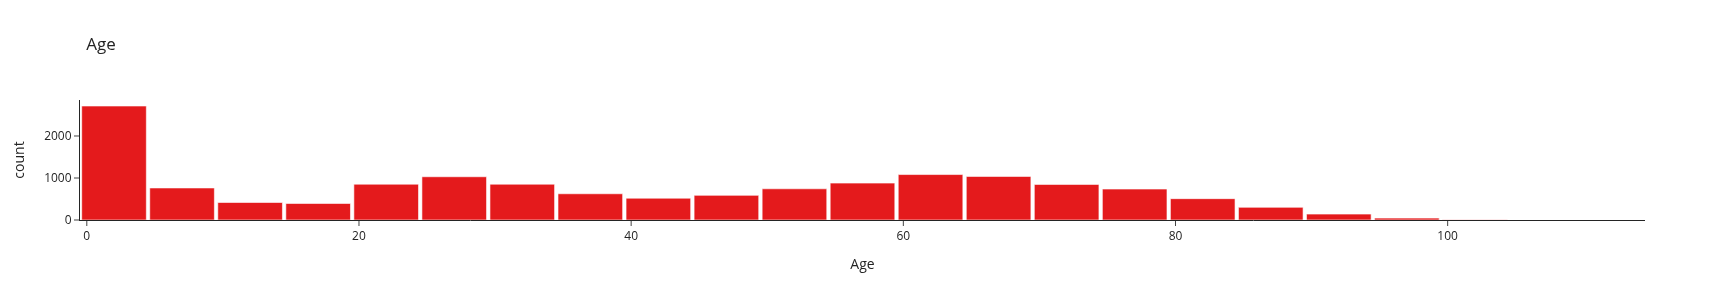

In [10]:
df2 = df.drop_duplicates(subset=['Patient ID'])

fig = px.histogram(
    df2,
    x="Age",
    nbins=30,
    title="Age",
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.update_layout(
    template="simple_white",
    bargap=0.05,  # optional: small gap between bars
    height=300
)

fig.show()

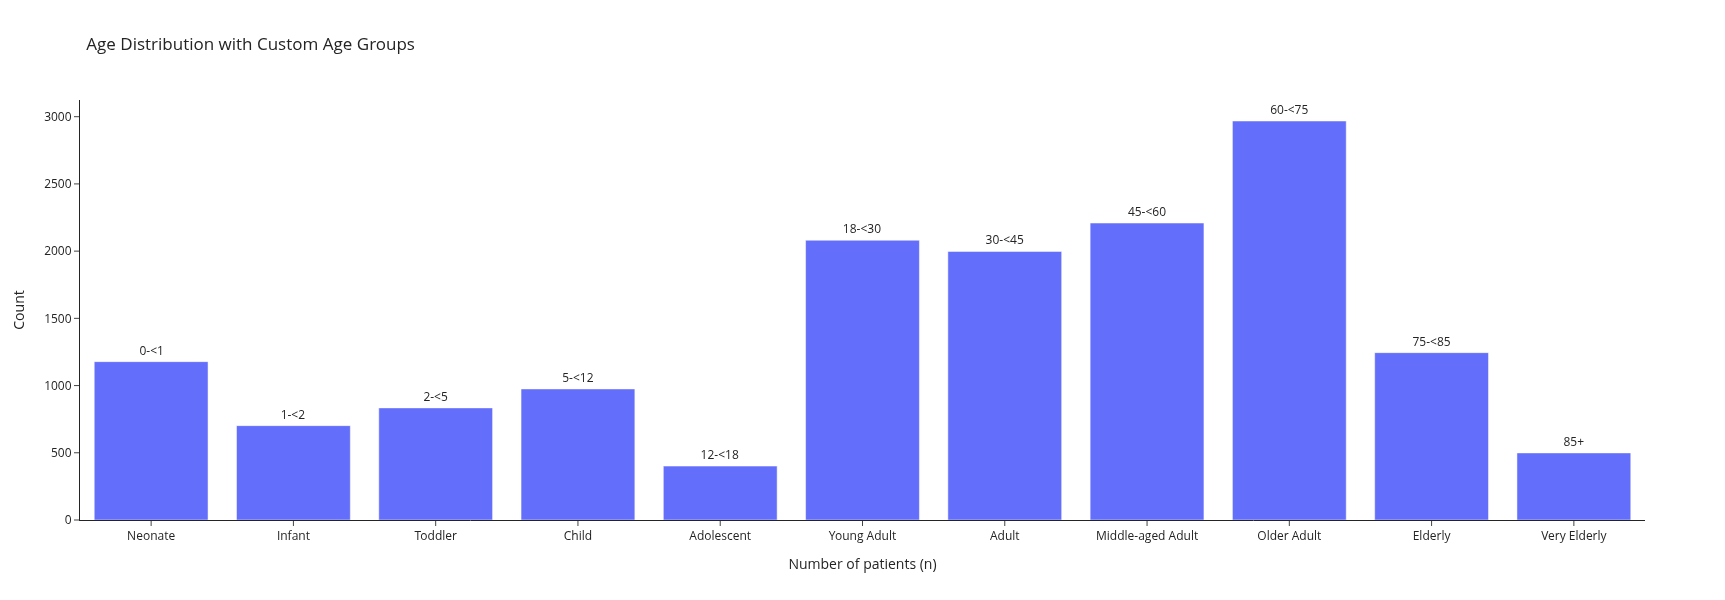

In [11]:
plot_df = count_entries("Age Group")

age_range_labels = {
    k: f"{v[0]}-<{int(v[1])}" if v[1] != float('inf') else f"{int(v[0])}+"
    for k, v in age_groups.items()
}
plot_df["Label"] = plot_df["Age Group"].map(age_range_labels)

# Plot histogram with custom age groups using Plotly Express
fig = px.bar(plot_df,
             x='Age Group',
             y="Count",
             text='Label',
             title='Age Distribution with Custom Age Groups',
             labels={'Age Group': 'Age Group', 'count': 'Count'})

fig.update_layout(
    template="simple_white",
    height=600,
    xaxis=dict(
        title="Number of patients (n)",
        categoryorder='array',
        categoryarray=list(age_groups.keys())
    )
)
fig.update_traces(textposition='outside')
fig.show()

## Date of Request

In [12]:
for yr in yrs:
    yr = int(yr)
    earliest = df.loc[df["Year"] == yr, :]["Date of Request"].min()
    latest = df.loc[df["Year"] == yr, :]["Date of Request"].max()
    
    
    print(f"""Year: {yr},
    Earliest: {earliest},
    Latest: {latest}""")
    print()

Year: 2020,
    Earliest: 2020-01-01 00:00:00,
    Latest: 2020-12-01 00:00:00

Year: 2021,
    Earliest: 2021-01-01 00:00:00,
    Latest: 2021-12-01 00:00:00

Year: 2022,
    Earliest: 2022-01-01 00:00:00,
    Latest: 2022-12-01 00:00:00

Year: 2023,
    Earliest: 2023-01-01 00:00:00,
    Latest: 2023-12-31 09:14:28



Something weird going on with the date:

- Most of the years, sample collection ended on 1st Dec?
- Earliest sample on 2023 is on 1st June?

## Ward

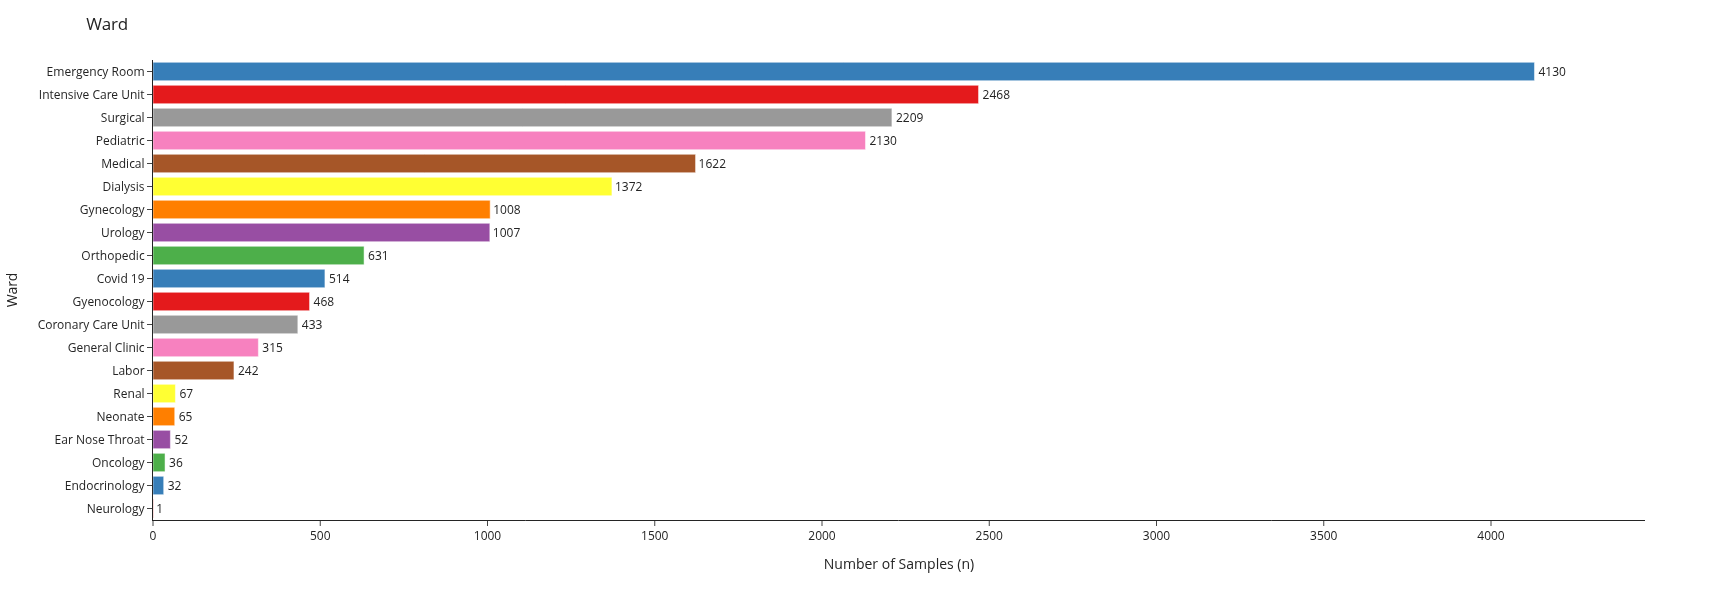

In [13]:
# Prepare data
plot_df = count_entries("Ward", nonorm=True)

fig = px.bar(
    plot_df, x='Count', y='Ward', text='Count', color='Ward',
    orientation='h', color_discrete_sequence=px.colors.qualitative.Set1,
)

fig.update_layout(
    title='Ward', template="simple_white",
    xaxis=dict(
        title="Number of Samples (n)",
        range=[0, plot_df['Count'].max() * 1.08]
    ),
    yaxis=dict(
        categoryorder='array',
        categoryarray=plot_df['Ward'].tolist()  # maintain ascending order
    ),
    showlegend=False,
    height=600
)

fig.update_traces(textposition='outside')
fig.show()

## Type of Sample

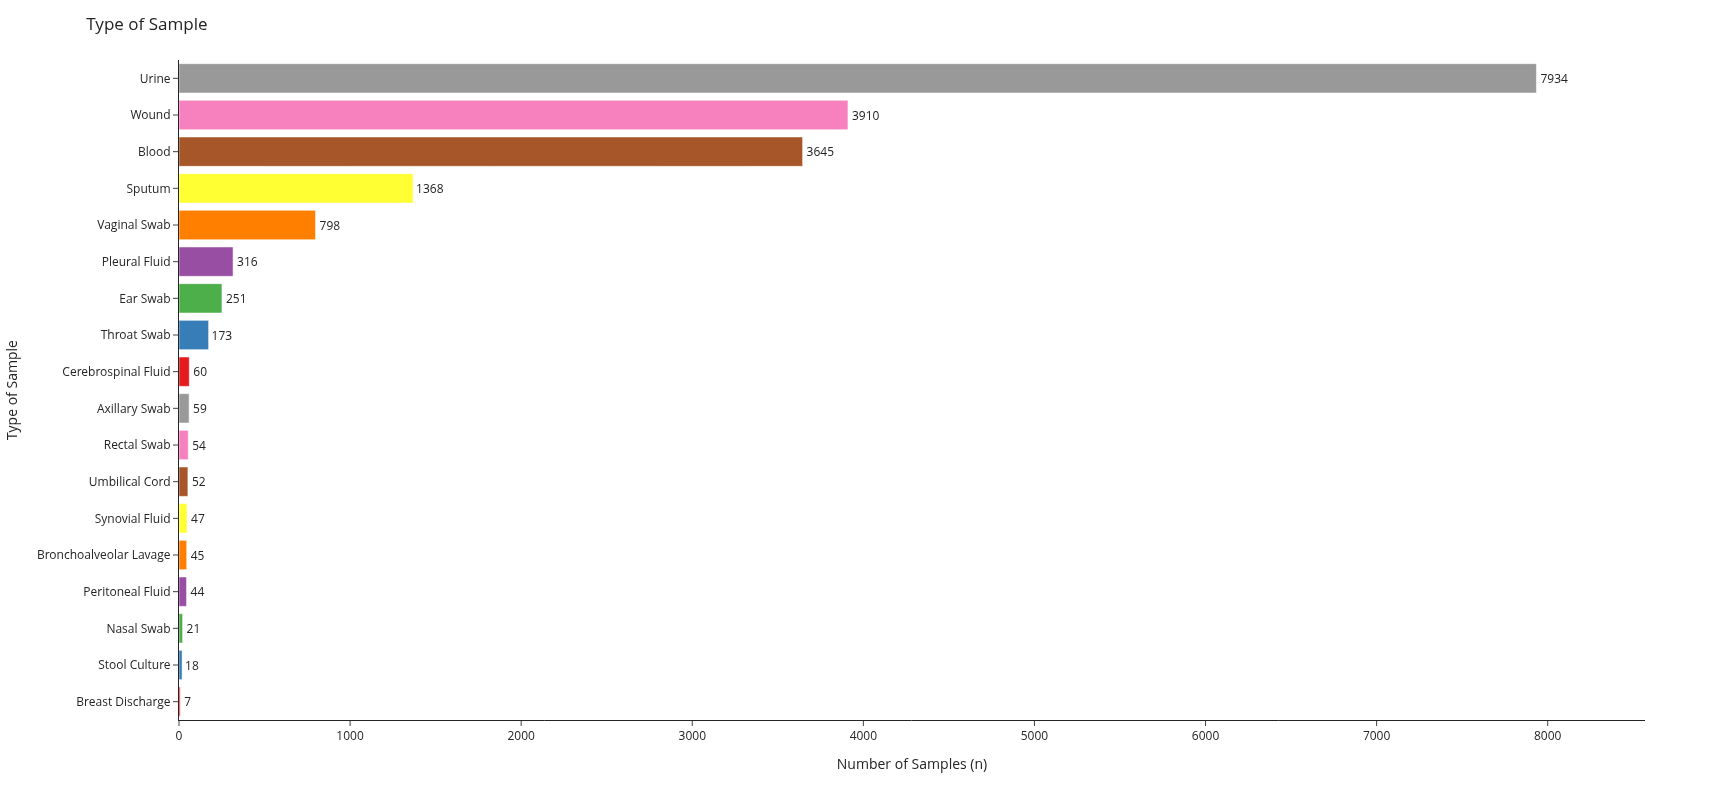

In [14]:
# Prepare data
plot_df = count_entries("Type of Sample", nonorm=True)

# Plotly Express bar plot
fig = px.bar(
    plot_df, x='Count', y='Type of Sample', orientation='h',
    text='Count', color='Type of Sample',
    color_discrete_sequence=px.colors.qualitative.Set1
)

# Layout tweaks
fig.update_layout(
    title='Type of Sample', template="simple_white",
    xaxis=dict(
        title="Number of Samples (n)",
        range=[0, plot_df['Count'].max() * 1.08]),
    yaxis=dict(
        categoryorder='array',
        categoryarray=plot_df['Type of Sample'].tolist()
    ),
    showlegend=False,
    height=800
)

# Show count outside bars
fig.update_traces(textposition='outside')
fig.show()

## Organism

In [15]:
org = df['Organism'].value_counts().to_dict()
org = dict(sorted(org.items()))
all_organisms = list(org.keys())

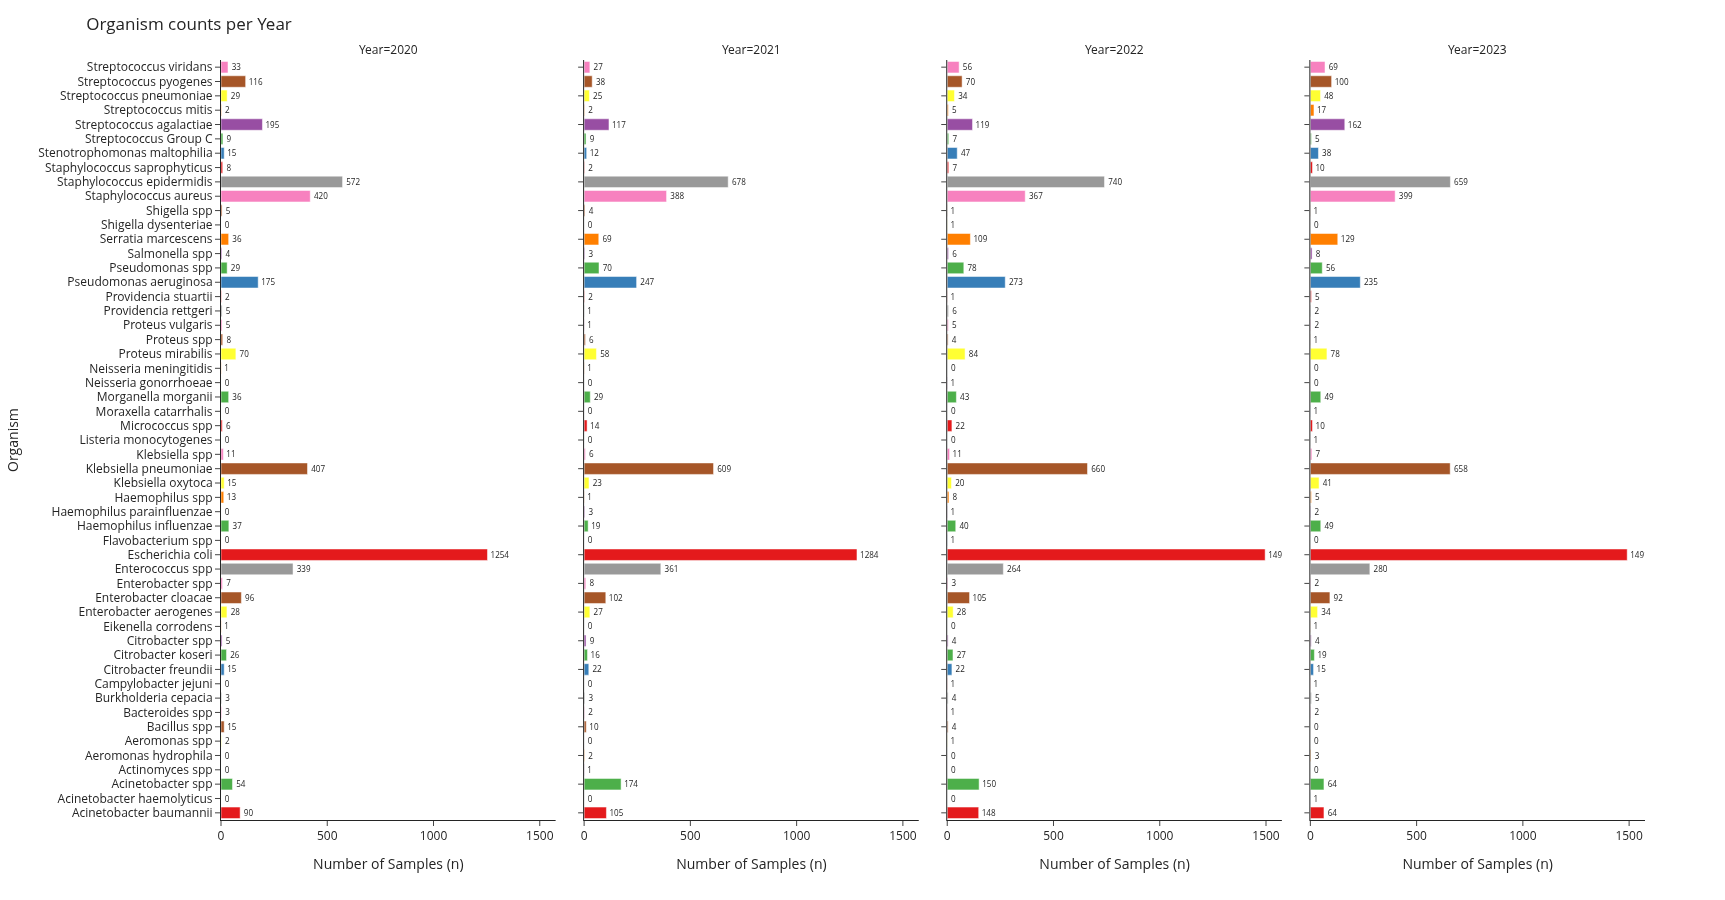

In [16]:
# Build a new DataFrame for plotting
plot_df = []

for yr in yrs:
    yr = int(yr)
    subset = df[df["Year"] == yr].value_counts("Organism")
    subset = subset.reindex(all_organisms, fill_value=0)
    subset = subset.reset_index()
    subset.columns = ["Organism", "Count"]
    subset["Year"] = yr
    plot_df.append(subset)

plot_df = pd.concat(plot_df, ignore_index=True)

# Create faceted bar plot
fig = px.bar(
    plot_df, x="Count", y="Organism", facet_col="Year", orientation="h",
    color="Organism", text="Count", color_discrete_sequence=px.colors.qualitative.Set1
)

# Fix axis order across facets
for axis in fig.layout:
    if axis.startswith('yaxis'):
        fig.layout[axis].update(
            categoryorder='array',
            categoryarray=all_organisms
        )

# Set x-axis title for all subplots
fig.update_xaxes(title_text="Number of Samples (n)")
        
# Customize layout
fig.update_layout(
    height=900, template="simple_white",
    title="Organism counts per Year",
    showlegend=False,
    )

# Ensure consistent y-axis order across facets
fig.update_traces(textposition='outside')
fig.update_yaxes(categoryorder='array', categoryarray=all_organisms)
fig.show()

## Type of AMR

In [17]:
amrs = df['Type of AMR'].value_counts().to_dict()
amrs = dict(sorted(amrs.items()))
all_amrs = list(amrs.keys())

Types of AMR:

In [18]:
all_amrs

['AMP-RHI',
 'CR-AB',
 'CR-PA',
 'CRE',
 'ESBL-EC',
 'ESBL-KP',
 'MAC-RSP',
 'MAC-RSPN',
 'MRSA',
 'VRE']

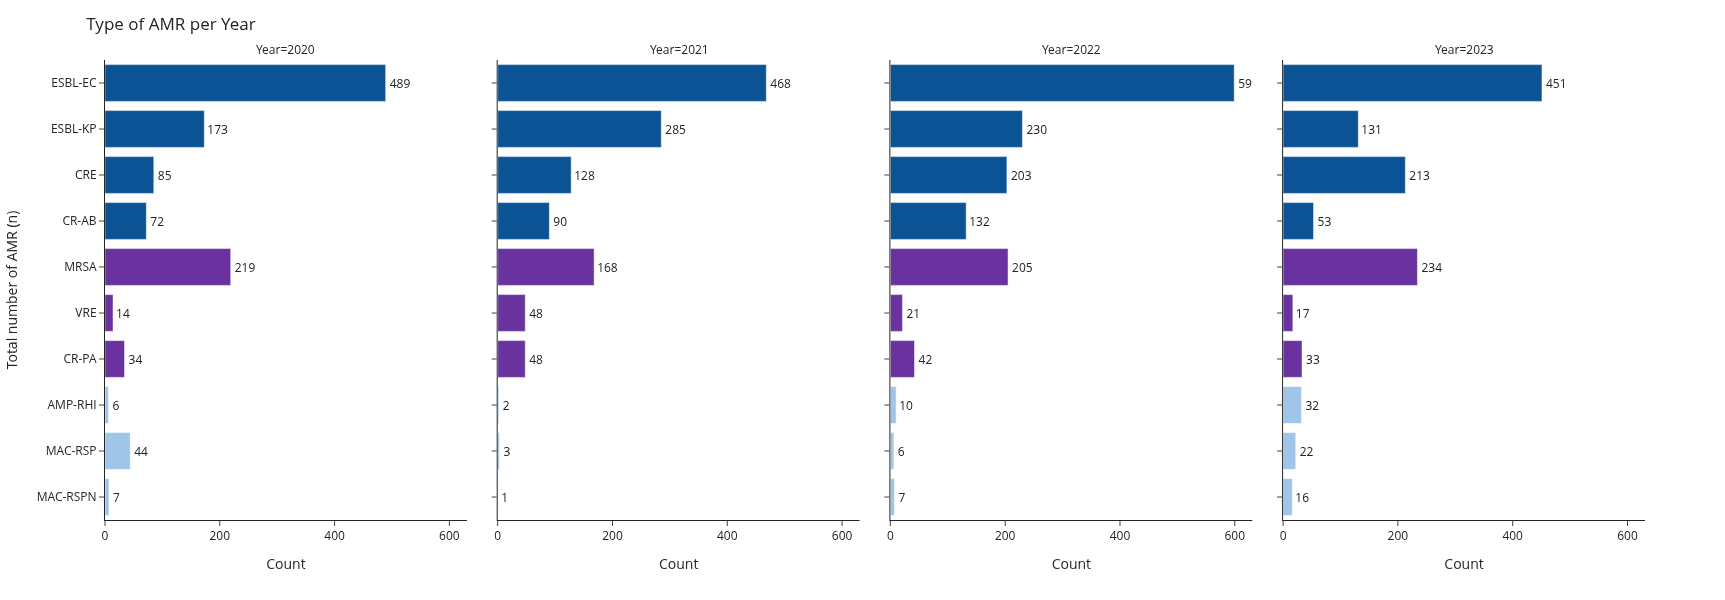

In [19]:
plot_df = []

for yr in yrs:
    yr = int(yr)
    subset = df[df["Year"] == yr].value_counts("Type of AMR")
    subset = subset.reindex(all_amrs, fill_value=0).reset_index()
    subset.columns = ["Type of AMR", "Count"]
    subset["Year"] = yr
    plot_df.append(subset)

plot_df = pd.concat(plot_df, ignore_index=True)
plot_df["Type of AMR"] = pd.Categorical(plot_df["Type of AMR"], categories=list(amr_custom_color_map.keys()), ordered=True)
plot_df = plot_df.sort_values(["Year", "Type of AMR"])

# Plotly Express faceted bar chart
fig = px.bar(
    plot_df, x="Count", y="Type of AMR", facet_col="Year",
    orientation="h", color="Type of AMR", text="Count",
    color_discrete_map=amr_custom_color_map2
    # color_discrete_sequence=px.colors.qualitative.Set1
)

# Layout adjustments
fig.update_layout(
    height=600, template="simple_white",
    title="Type of AMR per Year",
    showlegend=False,
    yaxis=dict(title="Total number of AMR (n)")
)

# Value labels outside bars
fig.update_traces(textposition='outside')

# Consistent y-axis category order
# fig.update_yaxes(categoryorder='array', categoryarray=all_amrs)

fig.show()

# QnA

1. What is the Number of samples per year?

In [20]:
df["Year"].value_counts()

Year
2022    5085
2023    4925
2021    4590
2020    4202
Name: count, dtype: int64

2. Which organism is the most frequently isolated across all years?

In [21]:
pd.DataFrame(df["Organism"].value_counts())

,count
Organism,
Escherichia coli,5525
Staphylococcus epidermidis,2649
Klebsiella pneumoniae,2334
Staphylococcus aureus,1574
Enterococcus spp,1244
Pseudomonas aeruginosa,930
Streptococcus agalactiae,593
Acinetobacter spp,442
Acinetobacter baumannii,407


3. What are the most common organisms isolated from the group of samples?

In [22]:
# Get list of sample types
tos = df['Type of Sample'].value_counts(ascending=False).index.tolist()

# Prepare dropdown
dropdown = widgets.Dropdown(
    options=tos,
    value=tos[0],
    description='Sample:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

# Output widget for plot
out = widgets.Output()

def plot_sample_type(t):
    sdf = df[df["Type of Sample"] == t]
    counts = sdf["Organism"].value_counts(ascending=True)

    if len(counts) > 10:
        top_counts = counts.iloc[-10:]
        original_index = top_counts.index.tolist()
        others_sum = counts.iloc[:-10].sum()
        top_counts["Others"] = others_sum
        final_index = ["Others"] + original_index
        top_counts = top_counts.loc[final_index]
    else:
        top_counts = counts

    plot_df = pd.DataFrame({
        "Organism": top_counts.index,
        "Count": top_counts.values
    })

    fig = px.bar(
        plot_df,
        x="Count",
        y="Organism",
        orientation="h",
        color="Organism",
        text="Count",
        title=f"Top Organisms Isolated from {t}",
        color_discrete_sequence=px.colors.qualitative.Set1
    )
    fig.update_traces(textposition="outside")
    fig.update_layout(showlegend=False, height=400, template="simple_white",)

    return fig

# Define callback
def update_plot(change):
    with out:
        clear_output(wait=True)
        fig = plot_sample_type(change["new"])
        fig.show()

# Observe dropdown changes
dropdown.observe(update_plot, names="value")

# Initial display
display(dropdown)
with out:
    fig = plot_sample_type(tos[0])
    fig.show()

display(out)

Dropdown(description='Sample:', layout=Layout(width='50%'), options=('Urine', 'Wound', 'Blood', 'Sputum', 'Vag…

Output()

4. What is the percentage of AMR from all the samples?

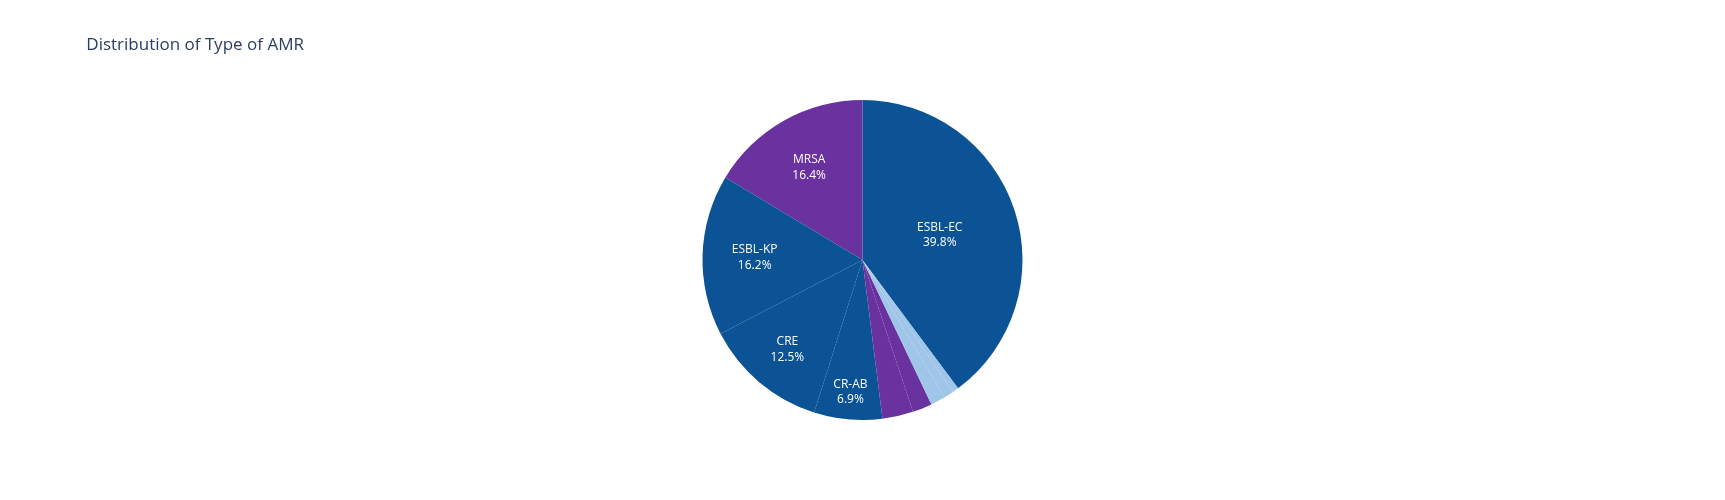

In [23]:
# Count occurrences
counts = df["Type of AMR"].value_counts()

# Prepare a DataFrame
plot_df = counts.reset_index()
plot_df.columns = ["Type of AMR", "Count"]

# Calculate percentages
plot_df["Percent"] = plot_df["Count"] / plot_df["Count"].sum() * 100

# Top 5 categories by count (as per your code)
top_n_indices = plot_df["Type of AMR"].head(5)

# Label only top categories and those with >5% share
plot_df["Label"] = plot_df.apply(
    lambda row: f"{row['Type of AMR']}<br>{row['Percent']:.1f}%" if row['Type of AMR'] in top_n_indices.values and row['Percent'] > 5 else "",
    axis=1
)

# Create the pie chart
fig = px.pie(
    plot_df,
    names="Type of AMR",
    values="Count",
    color="Type of AMR",  # required for color_discrete_map to work
    color_discrete_map=amr_custom_color_map2,
    title="Distribution of Type of AMR",
    hover_data=["Count", "Percent"]
)

fig.update_traces(
    text=plot_df["Label"],
    textinfo="text",
    hovertemplate="%{label}<br>Count: %{value}<br>Percent: %{percent}"
)

fig.update_layout(height=500, width=500, showlegend=False)
fig.show()

5. Which ward/clinic reports the highest rate of antimicrobial resistance?

In [24]:
amr = {}

for w in df["Ward"].unique():
    a = df.loc[df["Ward"] == w, :].value_counts("Type of AMR")
    amr[w] = a

amr = pd.DataFrame.from_dict(amr, orient="index")
amr["SUM"] = amr.sum(axis="columns")
amr.fillna(0.0, inplace=True)
amr.sort_values("SUM", ascending = False)

,ESBL-EC,MRSA,ESBL-KP,CR-AB,CRE,AMP-RHI,CR-PA,MAC-RSP,MAC-RSPN,VRE,SUM
Emergency Room,545.0,171.0,145.0,15.0,62.0,17.0,20.0,18.0,8.0,6.0,1007.0
Intensive Care Unit,146.0,126.0,133.0,145.0,261.0,1.0,52.0,4.0,5.0,26.0,899.0
Surgical,255.0,129.0,96.0,55.0,98.0,9.0,21.0,19.0,5.0,26.0,713.0
Medical,207.0,53.0,80.0,16.0,60.0,10.0,24.0,14.0,4.0,13.0,481.0
Pediatric,255.0,90.0,79.0,3.0,27.0,2.0,6.0,11.0,3.0,3.0,479.0
Urology,164.0,21.0,51.0,2.0,24.0,0.0,7.0,0.0,0.0,4.0,273.0
Dialysis,76.0,75.0,49.0,1.0,25.0,0.0,2.0,0.0,0.0,13.0,241.0
Covid 19,47.0,19.0,28.0,87.0,9.0,1.0,7.0,2.0,1.0,2.0,203.0
Gynecology,105.0,29.0,50.0,1.0,8.0,0.0,0.0,0.0,0.0,1.0,194.0
Orthopedic,49.0,48.0,31.0,15.0,28.0,1.0,9.0,4.0,1.0,4.0,190.0


6. Time series analysis for the AMR organisms by month?

### Narrow to only ESBL-EC, ESBL-KP, CRE and MRSA

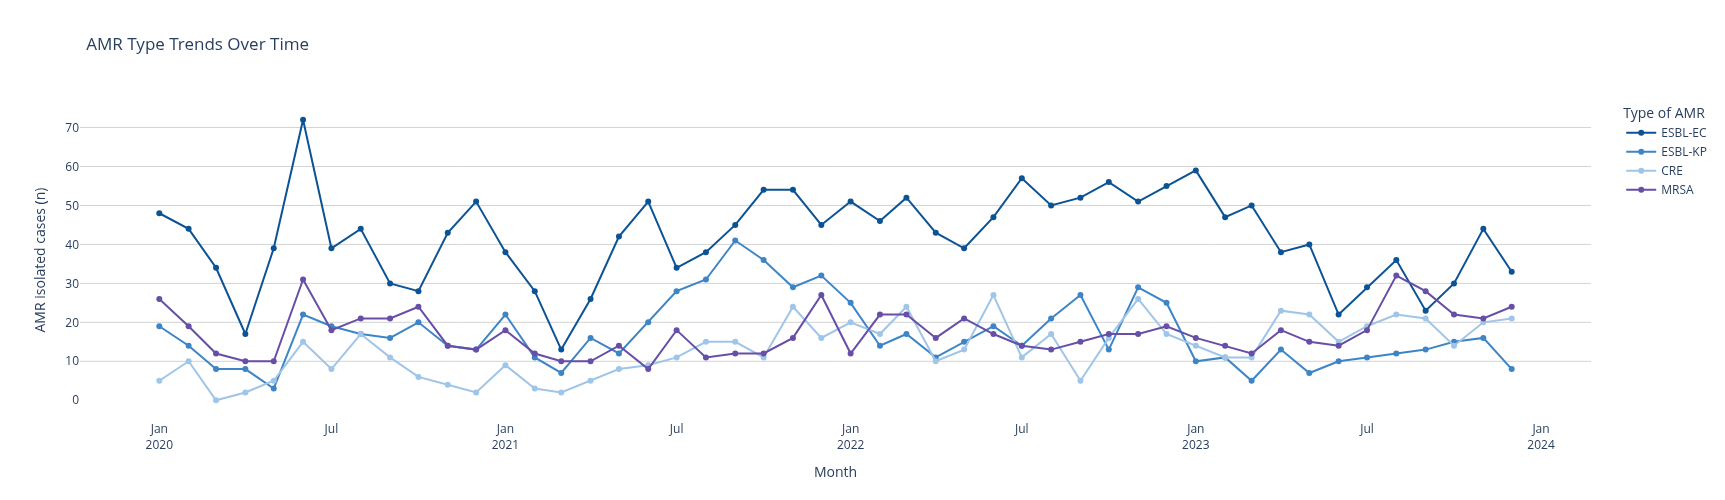

In [25]:
yms = []
for y in range(2020, 2024):
    for m in range(1, 13):
        yms.append(f"{m}-{y}")

# Prepare dataframe
df2 = df.copy()
df2["Month-Year"] = df2["Date of Request"].dt.month.astype(str) + "-" + df2["Date of Request"].dt.year.astype(str)

# Count AMR types per month-year
ts = {}
for my in yms:
    a = df2[df2["Month-Year"] == my]["Type of AMR"].value_counts()
    ts[my] = a

ts = pd.DataFrame.from_dict(ts, orient="index").fillna(0)

# Prepare for plotting
ts = ts.reset_index().melt(id_vars="index", var_name="Type of AMR", value_name="Count")
ts = ts.rename(columns={"index": "Month-Year"})

# Optional: sort Month-Year chronologically using datetime
ts["Month-Year"] = pd.to_datetime(ts["Month-Year"], format="%m-%Y")
ts["Type of AMR"] = pd.Categorical(ts["Type of AMR"], categories=list(amr_custom_color_map.keys()), ordered=True)
ts = ts.sort_values(["Month-Year", "Type of AMR"])

selected_AMR = ["ESBL-EC", "ESBL-KP", "CRE", "MRSA"]

ts2 = ts.loc[ts["Type of AMR"].isin(selected_AMR), :].copy()

# Plot with Plotly Express
fig = px.line(
    ts2,
    x="Month-Year",
    y="Count",
    color="Type of AMR",
    markers=True,
    title="AMR Type Trends Over Time",
    color_discrete_map=amr_custom_color_map
    # color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(
    xaxis=dict(
        title="Month",
        tickformat="%b\n%Y",
        showgrid=True  # optional: hide vertical gridlines
    ),
    yaxis=dict(
        title="AMR isolated cases (n)",
        showgrid=True,  
        gridcolor='lightgrey',  # optional: lighter gridlines
        gridwidth=1
    ),
    legend_title="Type of AMR",
    hovermode="x unified",
    height=500,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()

7. Is there a correlation between patient age and Type of AMR Infections?

8. What percentage of E. coli isolates are ESBL-positive?

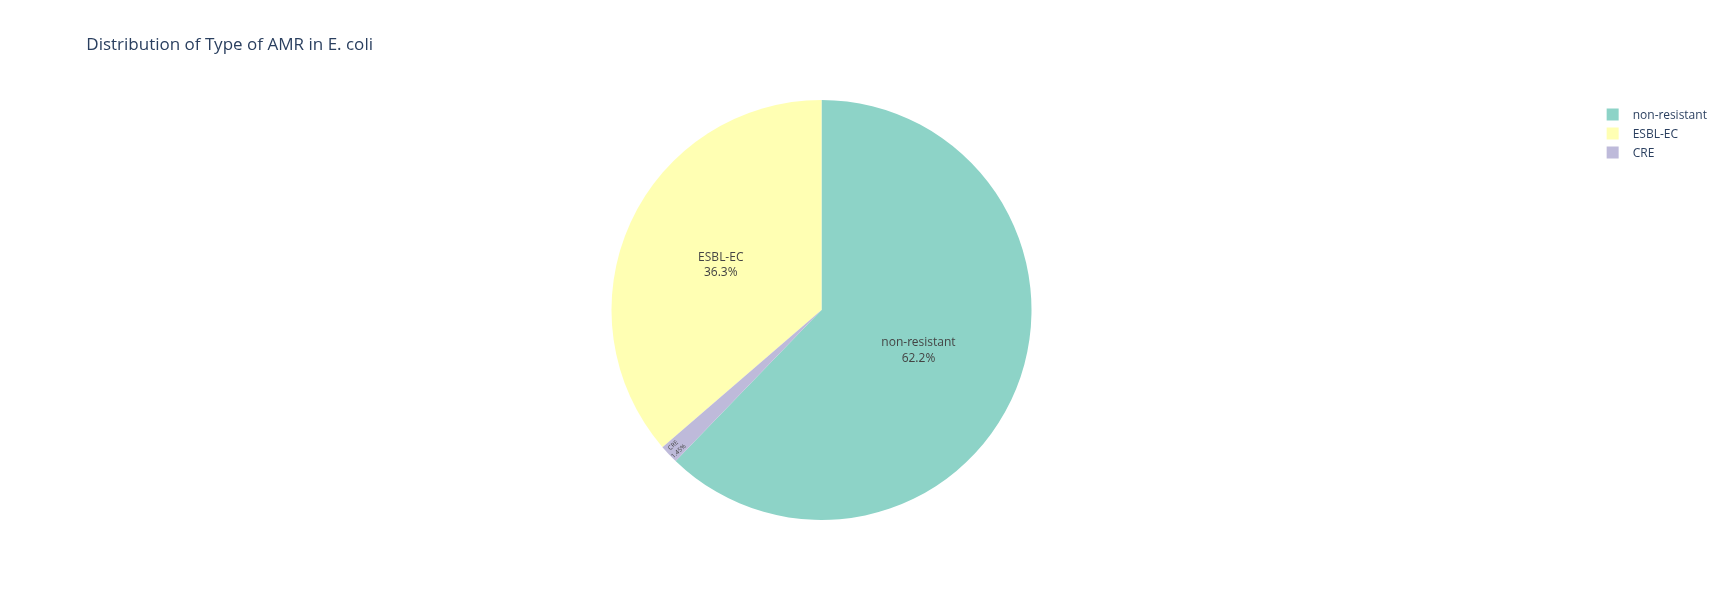

In [26]:
ecoli = df[df["Organism"] == "Escherichia coli"].copy()
ecoli["Type of AMR"] = ecoli["Type of AMR"].fillna("non-resistant")

counts = ecoli["Type of AMR"].value_counts().reset_index()
counts.columns = ["Type of AMR", "Count"]

# Plotly pie chart
fig = px.pie(
    counts,
    names="Type of AMR",
    values="Count",
    title="Distribution of Type of AMR in E. coli",
    color_discrete_sequence=px.colors.qualitative.Set3,
    hole=0  # full pie chart, set to 0.3 for donut
)

# Add percentage labels
fig.update_traces(textinfo="percent+label", textposition="inside")

fig.update_layout(
    height=600,
    showlegend=True
)

fig.show()

9. What percentage of Klebsiella pneumoniae isolates are ESBL-positive?

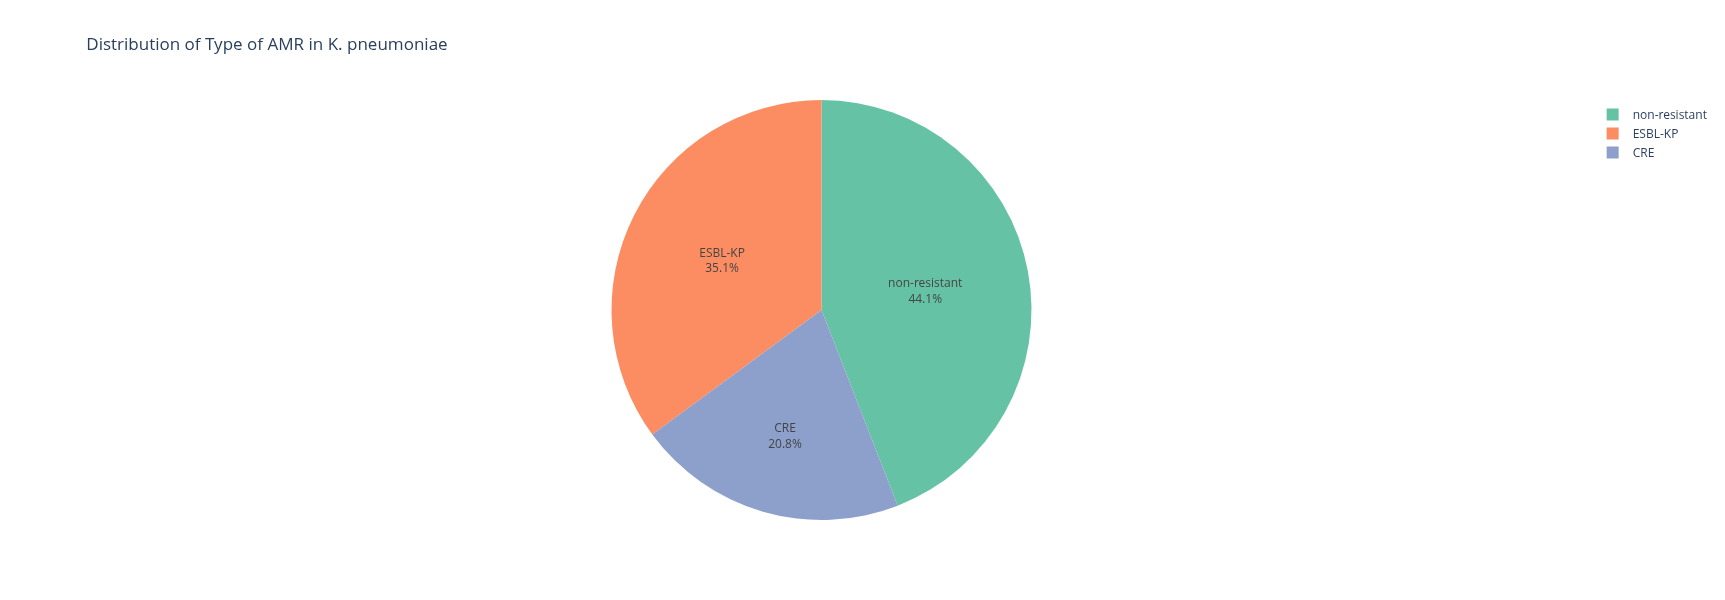

In [27]:
# Filter and prepare data
kp = df[df["Organism"] == "Klebsiella pneumoniae"].copy()
kp["Type of AMR"] = kp["Type of AMR"].fillna("non-resistant")

counts = kp["Type of AMR"].value_counts().reset_index()
counts.columns = ["Type of AMR", "Count"]

# Plotly pie chart
fig = px.pie(
    counts,
    names="Type of AMR",
    values="Count",
    title="Distribution of Type of AMR in K. pneumoniae",
    color_discrete_sequence=px.colors.qualitative.Set2,
    hole=0  # full pie chart
)

# Add percentage labels inside
fig.update_traces(textinfo="percent+label", textposition="inside")

fig.update_layout(
    height=600,
    showlegend=True
)

fig.show()

10. What percentage of Pseudomonas aeruginosa isolates are CR-PA?

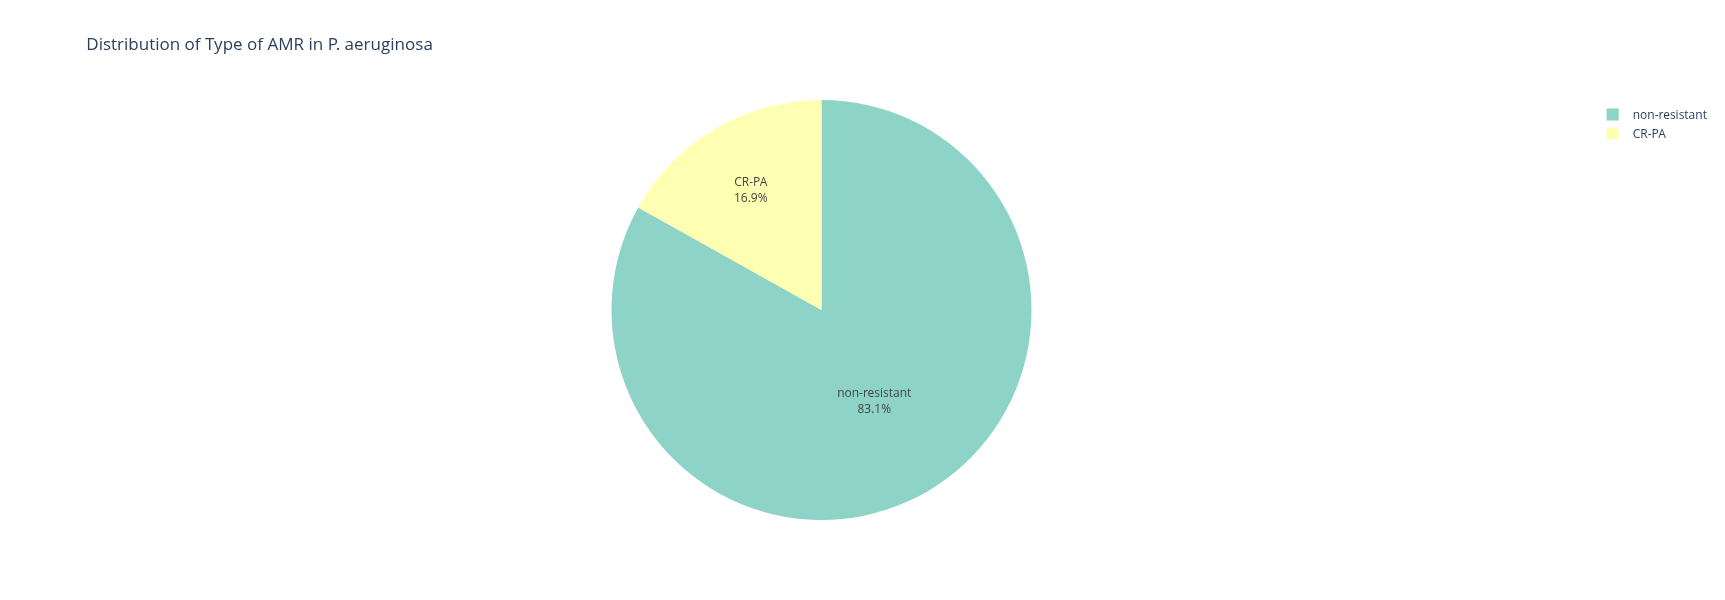

In [28]:
# Filter and prepare data
pa = df[df["Organism"] == "Pseudomonas aeruginosa"].copy()
pa["Type of AMR"] = pa["Type of AMR"].fillna("non-resistant")

counts = pa["Type of AMR"].value_counts().reset_index()
counts.columns = ["Type of AMR", "Count"]

# Plotly pie chart
fig = px.pie(
    counts,
    names="Type of AMR",
    values="Count",
    title="Distribution of Type of AMR in P. aeruginosa",
    color_discrete_sequence=px.colors.qualitative.Set3,
    hole=0  # full pie chart
)

# Add percentage labels inside
fig.update_traces(textinfo="percent+label", textposition="inside")

fig.update_layout(
    height=600,
    showlegend=True
)

fig.show()

11. What sample type contributes the most to ESBL-producing E. coli detection?

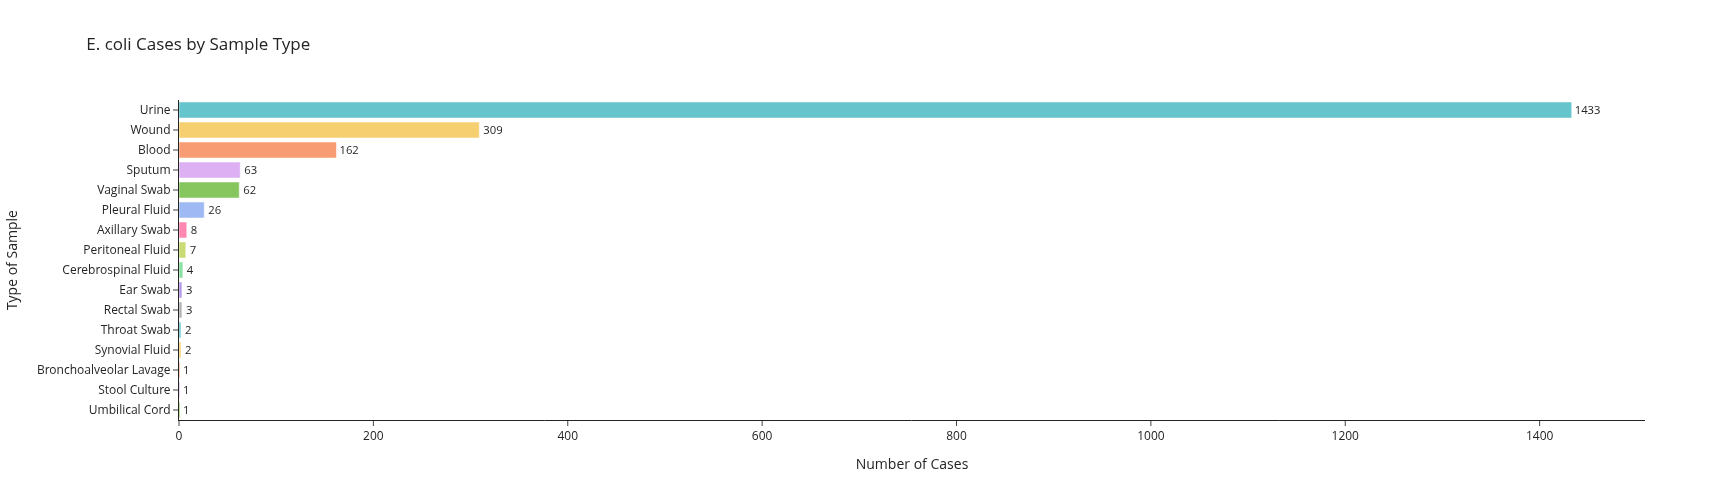

In [29]:
# Filter and prepare data
ecoli = df[df["Organism"] == "Escherichia coli"].copy()
ecoli["Type of AMR"] = ecoli["Type of AMR"].fillna("non-resistant")
ecoli = ecoli[ecoli["Type of AMR"] != "non-resistant"]

counts = ecoli["Type of Sample"].value_counts(ascending=False).reset_index()
counts.columns = ["Type of Sample", "Count"]

# Plotly bar chart (horizontal)
fig = px.bar(
    counts,
    x="Count",
    y="Type of Sample",
    orientation="h",
    title="E. coli Cases by Sample Type",
    text="Count",
    color="Type of Sample",
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_layout(
    yaxis_title="Type of Sample",
    xaxis_title="Number of Cases",
    showlegend=False,
    height=500,
    template="simple_white"
)

fig.update_traces(textposition="outside")

fig.show()

12. Are there particular wards or patient groups with a higher prevalence of ESBL-producing organisms?

In [30]:
map_amr_to_org = {
    "ESBL-EC": ["Escherichia coli"],
    "ESBL-KP": ["Klebsiella pneumoniae"],
    "MRSA": ["Staphylococcus aureus"],
    "CR-AB": ["Acinetobacter baumannii"],
    "CRE": ["Escherichia coli", "Klebsiella pneumoniae", 'Enterobacter cloacae'],
}

In [31]:
[i for i in sorted(df["Organism"].unique()) if "clo" in i]

['Enterobacter cloacae']

In [32]:
def make_amr_dashboard(category):
    # === UI ===
    dropdown = widgets.Dropdown(
        options=list(map_amr_to_org.keys()),
        description="AMR Type:",
    )

    checkbox = widgets.Checkbox(
        value=True,
        description='Show %'
    )

    controls = widgets.HBox([dropdown, checkbox])
    output = widgets.Output()

    # === Callback ===
    def update_plot(*args):
        target_amr = dropdown.value
        show_percent = checkbox.value
        target_organisms = map_amr_to_org[target_amr]

        # Step 1: Count totals
        df2 = df[df["Organism"].isin(target_organisms)]
        df2 = df2.groupby(['Year', category]).size().reset_index(name="target_organism")

        df3 = df[df["Type of AMR"] == target_amr]
        df3 = df3.groupby(['Year', category]).size().reset_index(name=target_amr)

        # Step 2: Merge and compute percentage
        merged = pd.merge(df2, df3, on=['Year', category], how='left').fillna(0)
        merged["Percent"] = (merged[target_amr] / merged["target_organism"] * 100).round(1)

        # Optional: reorder y-axis categories
        sort_y = df2.groupby(category)["target_organism"].sum().sort_values().index.tolist()
        
        def simplify_species_name(species_name):
            n1, n2 = species_name.split(" ")
            return f"{n1[0]}. {n2}"
        
        # Step 3: Melt for plotting both bars
        label_for_total = f"All {' & '.join(target_organisms)} samples"
        label_for_total_sp_only = [simplify_species_name(to) for to in target_organisms]
        # print(label_for_total_sp_only)
        if len(label_for_total_sp_only) == 1:
            label_for_total_sp_only = label_for_total_sp_only[0]
        else:
            label_for_total_sp_only = "Enterobacteriaceae"
            # print(label_for_total_sp_only)
        # print(label_for_total_sp_only)
        # f"{', '.join(target_organisms)}"
        plot_df = pd.melt(
            merged,
            id_vars=['Year', category, 'Percent'],
            value_vars=["target_organism", target_amr],
            var_name='Category',
            value_name='Count'
        )
        
        plot_df["Category"] = plot_df["Category"].replace({"target_organism": label_for_total_sp_only})
        
        # Step 4: Add text only for AMR category if checkbox is on
        plot_df["Text"] = plot_df.apply(
            lambda row: f"{row['Percent']}%" if show_percent and row['Category'] == target_amr else "",
            axis=1
        )

        # Step 5: Plot
        fig = px.bar(
            plot_df,
            x="Count",
            y=category,
            color="Category",
            facet_col="Year",
            orientation='h',
            barmode="overlay",
            text="Text",
            title=f"{target_amr} Cases as % of Total {label_for_total_sp_only}, count by {category}",
            color_discrete_map={
                label_for_total_sp_only: "#b4b4b4",
                target_amr: "#00bb00"
            }
        )

        fig.update_traces(textposition='outside')
        fig.update_yaxes(categoryorder='array', categoryarray=sort_y)
        fig.update_layout(height=600, template="simple_white",
                          yaxis=dict(title=f" Number of {label_for_total_sp_only} isolates"))

        with output:
            clear_output(wait=True)
            fig.show()

    # Register callbacks
    dropdown.observe(update_plot, names='value')
    checkbox.observe(update_plot, names='value')

    # Display UI
    display(widgets.VBox([controls, output]))

    # Trigger initial plot
    update_plot()
    
make_amr_dashboard("Ward")

In [33]:
make_amr_dashboard("Type of Sample")

13. What are the trends in antibiotic resistance among E. coli, Klebsiella pneumoniae, Acinetobacter baumannii, and Staphylococcus aureus over the four years?

** maybe you want to check out these numbers first

In [34]:
def count_amr_in_species(species):
    counyer = df.loc[df["Organism"] == species, :]
    counyer.loc[:, "Type of AMR"] = counyer.loc[:, "Type of AMR"].fillna("non-resistant")

    e1 = {}

    for yr in range(2020, 2024):
        d = counyer.loc[counyer["Year"] == yr, :].groupby("Type of AMR").count()["Sample ID"]
        e1[yr] = d

    return pd.DataFrame(e1)

Escherichia coli

In [35]:
count_amr_in_species("Escherichia coli")

,2020,2021,2022,2023
Type of AMR,,,,
CRE,17,15,25,23
ESBL-EC,489,468,599,451
non-resistant,748,801,872,1017


Klebsiella pneumoniae

In [36]:
count_amr_in_species("Klebsiella pneumoniae")

,2020,2021,2022,2023
Type of AMR,,,,
CRE,60,92,162,172
ESBL-KP,173,285,230,131
non-resistant,174,232,268,355


Acinetobacter baumannii

In [37]:
count_amr_in_species("Acinetobacter baumannii")

,2020,2021,2022,2023
Type of AMR,,,,
CR-AB,72,90,132,53
non-resistant,18,15,16,11


Staphylococcus aureus

In [38]:
count_amr_in_species("Staphylococcus aureus")

,2020,2021,2022,2023
Type of AMR,,,,
MRSA,219,168,205,234
non-resistant,201,220,162,165
